# Stitched waterfalls: the 29_n15 **8-17-26** scan — FBZ / Optimal / PFBZ, $\ell=1$

Same pipeline as [`waterfall_stitched_Full.ipynb`](waterfall_stitched_Full.ipynb), pointed at the
**8-17-26** acquisition and specialised to the single charge that was recorded that day:

`data/focusing_images/8-17-26/29_n15/{FBZ, Optimal, PFBZ}/{0mm-25mm, 20mm-45mm, 40mm-65mm}/l=1/`

Every condition is scanned in three overlapping segments whose `positions.csv` is *local* (each
restarts at 0.0), so a segment's true global $z$ is `local_z + offset`. The layout:

| condition | segments | charges |
|---|---|---|
| **FBZ**     | `0mm-25mm`, `20mm-45mm`, `40mm-65mm` | $\ell = 1$ |
| **Optimal** | `0mm-25mm`, `20mm-45mm`, `40mm-65mm` | $\ell = 1$ |
| **PFBZ**    | `0mm-25mm`, `20mm-45mm`, `40mm-65mm` | $\ell = 1$ |

The pipeline, per condition:

1. Process each segment independently with the base pipeline (centroid tracking → transverse slice →
   per-segment waterfall) on its *local* $z$, plus a per-frame **RMS beam-width** trace and the raw
   clipping/on-axis diagnostics.
2. Place segment $k$ at `local_z + STARTS_MM[cond][ℓ][seg]` (absolute global starts, hand-set in
   `waterfall_offsets_8-17-26.csv`).
3. **Stitch** onto one common global-$z$ grid (linear interpolation in $z$), blending overlapping
   segments — *crossfade*, *average*, or *hardcut*.
4. Draw the stitched waterfalls, **RMS** beam-width curves, a single **RMS-vs-LG** comparison, the
   clipping/saturation diagnostics, the centroid diagnostic, and a summary table.

Outputs go under `outputs/waterfalls_stitched_8-17-26/<condition>/`.

> **Width metric.** Every width/waist figure uses the **measured RMS radius** (intensity-weighted
> second moment of the transverse cut), *except* the one clearly-labelled comparison section, which
> overlays the RMS against a per-frame Laguerre–Gaussian $\ell=1$ fit so the two can be judged
> against each other.

> **Clipping.** The camera is 10-bit and pins at **1022 counts**. Unlike the over-exposed 7-27
> $\ell=1$ scan, **no frame in this acquisition saturates** (per-segment peaks 14–702 cts), so the
> clipping section confirms clean, unbiased widths rather than diagnosing a problem. Note the
> `0mm-25mm` segments are very dim (peak ≲40 cts, far from focus) — expect a noisier width/centroid
> there; the informative focus region sits in the `40mm-65mm` segment.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    '''Walk up to the directory holding pyproject.toml (see the base notebook).'''
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
SCAN_ROOT = DATA_ROOT / "8-17-26" / "29_n15"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfalls_stitched_8-17-26"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"repo root : {REPO_ROOT}")
print(f"scan root : {SCAN_ROOT}")
print(f"figures   : {OUT_ROOT}")
assert SCAN_ROOT.is_dir(), f"missing {SCAN_ROOT}"

repo root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
scan root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/data/focusing_images/8-17-26/29_n15
figures   : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/outputs/waterfalls_stitched_8-17-26


## Tunables

`CONDITION_SEGMENTS` is an **ordered** mapping — one entry per condition, each listing its segment
folders in chain order. `ELLS` is `[1]` for this acquisition. The slicing / centroid knobs are copied
verbatim from the base notebook so the analyses stay directly comparable, plus `SAT_LEVEL` (the
10-bit clip level) for the clipping diagnostic.

In [2]:
RUN = "29_n15_8-17-26"

# Segment folder name -> nominal global start (mm), parsed from the "AmmBmm" folder name.
def nominal_start(folder_name: str) -> float:
    m = re.match(r"(\d+)mm-(\d+)mm", folder_name)
    if not m:
        raise ValueError(f"cannot parse a nominal start from folder {folder_name!r}")
    return float(m.group(1))


CONDITION_SEGMENTS = {
    "FBZ":     ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
    "Optimal": ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
    "PFBZ":    ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
}

ELLS = [1]                           # only l=1 was recorded on 8-17-26

STEP_MM = 0.5                        # stage step; also the fallback if a positions.csv is odd

# --- slicing (verbatim from waterfall_plot.ipynb) -------------------------
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200

# --- centroid finding (verbatim) ------------------------------------------
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200

# --- clipping diagnostic --------------------------------------------------
SAT_LEVEL = 1022                     # 10-bit camera clip level (pixels pin here when saturated)
# --------------------------------------------------------------------------

if SLICE_AXIS not in ("x", "y"):
    raise ValueError(f"SLICE_AXIS must be 'x' or 'y', got {SLICE_AXIS!r}")

# Discover which (condition, segment, ell) folders actually exist.
for cond, seg_labels in CONDITION_SEGMENTS.items():
    cdir = SCAN_ROOT / cond
    assert cdir.is_dir(), f"missing condition folder {cdir}"
    for seg in seg_labels:
        assert (cdir / seg).is_dir(), f"missing segment folder {cdir / seg}"

print(f"slicing along {SLICE_AXIS}")
for cond, seg_labels in CONDITION_SEGMENTS.items():
    print(f"{cond:>8}: {' -> '.join(seg_labels)}")

slicing along x
     FBZ: 0mm-25mm -> 20mm-45mm -> 40mm-65mm
 Optimal: 0mm-25mm -> 20mm-45mm -> 40mm-65mm
    PFBZ: 0mm-25mm -> 20mm-45mm -> 40mm-65mm


## Frame loading, background, centroid — unchanged from the base notebook

Identical helpers: frames ordered by the trailing `_NNNN` index, loaded as `float32`;
background = median of a border strip; centroid = background-subtracted, thresholded intensity
centroid refined within a window. A `Segment` here is one `l=<n>` folder of one segment of one
condition.

In [3]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


@dataclass(frozen=True)
class Segment:
    '''One `l=<n>` folder within one segment of one condition.'''

    cond: str
    seg: str          # folder name, e.g. "0mm-25mm"
    ell: int
    directory: Path
    nominal_start_mm: float


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    '''Local z (mm) from positions.csv, falling back to index*STEP_MM if it is unusable.'''
    csv = directory / "positions.csv"
    if csv.is_file():
        table = pd.read_csv(csv)
        by_name = dict(zip(table["image"], table["position_mm"]))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
        print(f"  ! {directory.parent.name}/{directory.name}: positions.csv does not name every "
              f"frame — inferring local z = index * {STEP_MM} mm")
    else:
        print(f"  ! {directory.parent.name}/{directory.name}: no positions.csv — "
              f"inferring local z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())

## Process one segment into a waterfall + registration & clipping features

`process_segment` is the base notebook's `process_dataset`, extended to also return (a) a per-frame
**RMS beam-width** trace used for alignment and as the primary width metric, and (b) the raw
clipping diagnostics — per-frame maximum count and the number of pixels pinned at `SAT_LEVEL` —
computed on the *raw* frames before background subtraction.

In [4]:
@dataclass
class SegWaterfall:
    '''One segment of one ell: its waterfall on *local* z, plus registration & clipping features.'''

    cond: str
    seg: str
    ell: int
    nominal_start_mm: float
    waterfall: np.ndarray       # (n_z, n_s), NOT yet peak-normalised (raw, bg-subtracted)
    s_px: np.ndarray            # (n_s,) transverse coord about the centre
    z_local: np.ndarray         # (n_z,) local z (mm)
    centroid_y: np.ndarray          # FITTED straight-line centroid actually used
    centroid_x: np.ndarray
    centroid_y_raw: np.ndarray      # raw per-frame centroid, kept for diagnostics
    centroid_x_raw: np.ndarray
    centroid_w: np.ndarray          # per-frame brightness weight used in the fit
    width_px: np.ndarray        # (n_z,) transverse RMS radius per frame
    onaxis: np.ndarray          # (n_z,) central-column intensity per frame (bg-subtracted cts)
    frame_max_raw: np.ndarray   # (n_z,) raw per-frame max (saturation check)
    n_saturated: np.ndarray     # (n_z,) count of pixels pinned at SAT_LEVEL per frame


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def segment_raw_centroids(segment: Segment):
    """Pass 1: load a segment's frames and return (z_local, centroid_y,
    centroid_x, weight) -- the RAW per-frame centroid and brightness, before the
    shared straight-line fit."""
    paths = frame_paths(segment.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {segment.directory}")
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3): row, col, brightness
    return z_local, cen[:, 0], cen[:, 1], cen[:, 2]


def process_segment(segment: Segment, centroid_y: np.ndarray, centroid_x: np.ndarray,
                    centroid_y_raw: np.ndarray, centroid_x_raw: np.ndarray,
                    centroid_w: np.ndarray) -> SegWaterfall:
    """Pass 2: build one segment's waterfall on the supplied FITTED straight-line
    centroid (no per-frame wobble).  Frames are reloaded here (released after the
    raw-centroid pass) so peak memory stays at a single segment."""
    paths = frame_paths(segment.directory)
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)

    frame_max_raw = frames.reshape(frames.shape[0], -1).max(axis=1)
    n_saturated = (frames >= SAT_LEVEL).reshape(frames.shape[0], -1).sum(axis=1)

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)  # raw, not peak-normalised
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return SegWaterfall(
        cond=segment.cond, seg=segment.seg, ell=segment.ell,
        nominal_start_mm=segment.nominal_start_mm,
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x,
        centroid_y_raw=centroid_y_raw, centroid_x_raw=centroid_x_raw, centroid_w=centroid_w,
        width_px=width_px, onaxis=onaxis,
        frame_max_raw=frame_max_raw, n_saturated=n_saturated,
    )

## Process every segment of every condition

Nine folders in all (3 conditions × 3 segments × $\ell=1$), 51 frames each. A missing `l=1` folder
inside a segment would simply be skipped.

In [5]:
# data[cond][ell][seg] = SegWaterfall
# Straight-line centroid, fit PER CONDITION: all of a condition's segments share
# ONE slope (the geometric beam walk-off per mm), each segment keeps its own
# offset; then build each segment on that smooth line instead of the wobbling
# per-frame centroid.
#   pass 1: raw per-frame centroid + brightness for every (ell, seg) of a condition
#   fit:    one shared-slope line per condition for both centroid axes
#   pass 2: rebuild each segment on its fitted line (frames reloaded, so peak
#           memory stays at a single segment).
from centroid_lines import fit_centroid_lines

data: dict[str, dict[int, dict[str, SegWaterfall]]] = {}

for cond, seg_labels in CONDITION_SEGMENTS.items():
    cdir = SCAN_ROOT / cond

    raw_sections: dict[tuple[int, str], dict] = {}
    segment_objs: dict[tuple[int, str], Segment] = {}
    for ell in ELLS:
        for seg in seg_labels:
            directory = cdir / seg / f"l={ell}"
            if not directory.is_dir():
                continue
            segment = Segment(cond, seg, ell, directory, nominal_start(seg))
            z_local, cy, cx, w = segment_raw_centroids(segment)
            raw_sections[(ell, seg)] = dict(z=z_local, cy=cy, cx=cx, w=w)
            segment_objs[(ell, seg)] = segment
    if not raw_sections:
        data[cond] = {}
        continue

    lines, (slope_y, slope_x) = fit_centroid_lines(raw_sections)

    data[cond] = {ell: {} for ell in ELLS}
    for (ell, seg), segment in segment_objs.items():
        r = raw_sections[(ell, seg)]
        cy_fit, cx_fit = lines[(ell, seg)]
        data[cond][ell][seg] = process_segment(
            segment, cy_fit, cx_fit, r["cy"], r["cx"], r["w"])
    data[cond] = {ell: segs for ell, segs in data[cond].items() if segs}
    print(f"{cond:>8}: centroid slope (y, x) = ({slope_y:+.3f}, {slope_x:+.3f}) px/mm; "
          + ", ".join(f"l{ell}:{len(data[cond][ell])}" for ell in data[cond]))

print("\ndone. per-condition (ell: n_segments):")
for cond in CONDITION_SEGMENTS:
    if data.get(cond):
        print(f"  {cond:>8}: " + ", ".join(f"l{ell}:{len(data[cond][ell])}" for ell in data[cond]))


     FBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']


 Optimal  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']


    PFBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']

done. per-condition (ell: n_segments):
       FBZ: l1:3
   Optimal: l1:3
      PFBZ: l1:3


## Set each segment's global start — edit `waterfall_offsets_8-17-26.csv`

Segment $k$'s global $z$ is `local_z + start_mm[cond][ell][seg]`. These are **absolute** global
starts, tuned independently. The reference (first) segment of every condition is pinned at 0.

This run uses its **own** offsets file, `waterfall_offsets_8-17-26.csv`, so it never collides with
the 7-27 run's `waterfall_offsets.csv`. Workflow:

1. Run this cell once — the file is created (seeded from the nominal folder starts plus the ~4 mm
   correction the earlier notebooks found) if it does not exist.
2. Edit the `start_mm` of any stitch in the CSV, save, and **re-run this cell and everything below**.

The file is only rewritten when stitches are added/removed, so hand-edits survive reruns. Use the
alignment-diagnostic and seam-zoom figures below to judge each value.

In [6]:
OFFSETS_FILE = REPO_ROOT / "waterfall_offsets_8-17-26.csv"

# Seed values by folder name (nominal + the ~4 mm correction the earlier notebooks found).
DEFAULT_START = {
    "0mm-25mm": 0.0,     # reference segment, pinned at 0
    "20mm-45mm": 24.0,
    "40mm-65mm": 44.5,
    "60mm-85mm": 64.5,
}


def default_for(seg: str) -> float:
    return DEFAULT_START.get(seg, nominal_start(seg))


needed = [(cond, ell, seg)
          for cond in CONDITION_SEGMENTS
          for ell in data[cond]
          for seg in data[cond][ell]]

existing: dict[tuple[str, int, str], float] = {}
if OFFSETS_FILE.is_file():
    prev = pd.read_csv(OFFSETS_FILE)
    for _, r in prev.iterrows():
        existing[(str(r["condition"]), int(r["ell"]), str(r["segment"]))] = float(r["start_mm"])

merged = {key: existing.get(key, default_for(key[2])) for key in needed}

offsets_df = pd.DataFrame(
    [{"condition": c, "ell": e, "segment": s,
      "nominal_start_mm": nominal_start(s), "start_mm": round(float(merged[(c, e, s)]), 3)}
     for (c, e, s) in needed]
)

added = [k for k in needed if k not in existing]
stale = [k for k in existing if k not in set(needed)]
if not OFFSETS_FILE.is_file():
    offsets_df.to_csv(OFFSETS_FILE, index=False)
    print(f"created {OFFSETS_FILE.name} with {len(needed)} stitches — "
          f"edit the start_mm column and re-run this cell")
elif added or stale:
    offsets_df.to_csv(OFFSETS_FILE, index=False)
    print(f"updated {OFFSETS_FILE.name}: +{len(added)} new, -{len(stale)} removed "
          f"({len(needed)} stitches total)")
else:
    print(f"loaded {len(needed)} offsets from {OFFSETS_FILE.name} (unchanged)")

STARTS_MM: dict[str, dict[int, dict[str, float]]] = {}
for (cond, ell, seg) in needed:
    STARTS_MM.setdefault(cond, {}).setdefault(ell, {})[seg] = float(merged[(cond, ell, seg)])

for cond in STARTS_MM:
    for ell, starts in STARTS_MM[cond].items():
        ref = next(iter(starts))
        assert starts[ref] == 0.0, (
            f"{cond} l={ell}: reference segment {ref!r} must have start_mm = 0.0 in "
            f"{OFFSETS_FILE.name} (it defines the global-z origin)")

for cond in CONDITION_SEGMENTS:
    print(f"== {cond} ==")
    for ell in data[cond]:
        parts = [f"{seg} @ {STARTS_MM[cond][ell][seg]:6.2f}" for seg in data[cond][ell]]
        print(f"  l={ell}: " + " | ".join(parts))

loaded 9 offsets from waterfall_offsets_8-17-26.csv (unchanged)
== FBZ ==
  l=1: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  43.50
== Optimal ==
  l=1: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  43.50
== PFBZ ==
  l=1: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  43.50


### Helpers shared by the per-condition figures

`seg_order(cond, ell)` is the chain order of the segments that exist for that $\ell$; `global_z`
places a segment's frames on the global axis; `seams(cond, ell)` are the consecutive pairs.

In [7]:
def seg_order(cond: str, ell: int) -> list[str]:
    '''Segments present for this (condition, ell), in chain order.'''
    return [s for s in CONDITION_SEGMENTS[cond] if s in data[cond][ell]]


def global_z(sw: SegWaterfall, ell: int) -> np.ndarray:
    '''A segment's frames on the global z axis, given the hand-set starts.'''
    return sw.z_local + STARTS_MM[sw.cond][ell][sw.seg]


def seams(cond: str, ell: int) -> list[tuple[str, str]]:
    order = seg_order(cond, ell)
    return list(zip(order[:-1], order[1:]))


def cond_out(cond: str) -> Path:
    d = OUT_ROOT / cond
    d.mkdir(parents=True, exist_ok=True)
    return d


SEG_COLOURS = {seg: f"C{i}" for i, seg in enumerate(
    ["0mm-25mm", "20mm-45mm", "40mm-65mm", "60mm-85mm"])}
SEG_MARKERS = {seg: m for seg, m in zip(
    ["0mm-25mm", "20mm-45mm", "40mm-65mm", "60mm-85mm"], ["o-", "^-", "s-", "d-"])}

### Check the offsets: do the RMS width curves line up?

One panel per condition ($\ell=1$): every segment's RMS beam-width trace on global $z$ at its
hand-set start (solid, coloured), plus — faint grey — each non-reference segment at its **nominal**
start. Vertical dashed lines mark the seams. A good set of starts has neighbouring curves lying on
top of each other through each shared band. This only *shows* the starts you set — no searching.

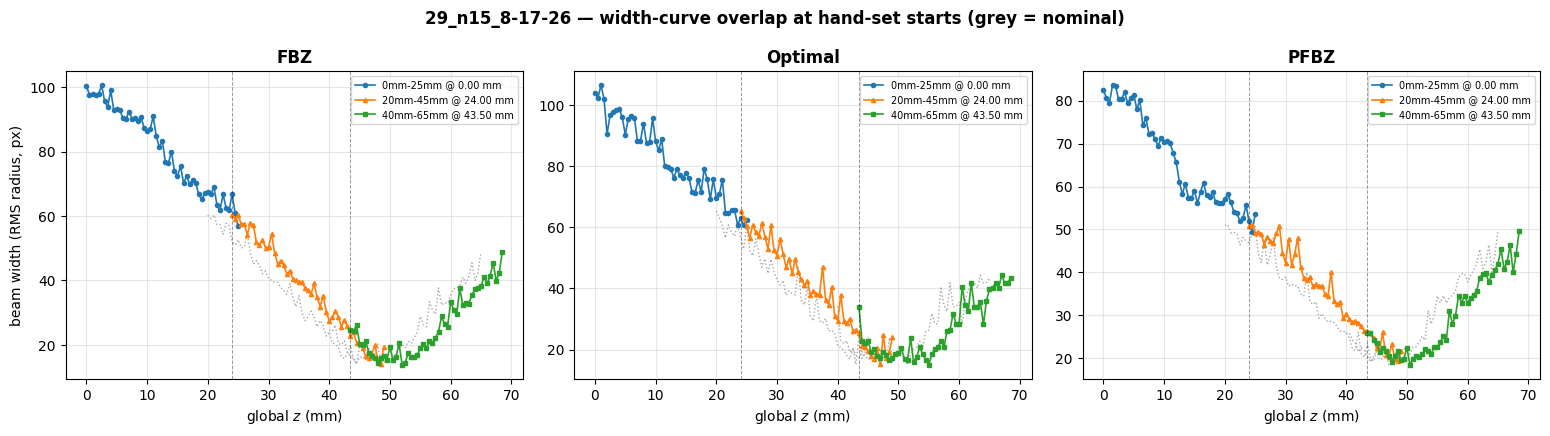

In [8]:
def plot_alignment():
    conds = list(CONDITION_SEGMENTS)
    fig, axes = plt.subplots(1, len(conds), figsize=(5.2 * len(conds), 4.4),
                             sharex=True, squeeze=False)
    for ax, cond in zip(axes[0], conds):
        for ell in data[cond]:                       # l=1 only, but stay general
            order = seg_order(cond, ell)
            ref = order[0]
            for seg in order:
                sw = data[cond][ell][seg]
                if seg != ref:
                    ax.plot(sw.z_local + sw.nominal_start_mm, sw.width_px, ":", ms=2.5, lw=1,
                            color="0.65", zorder=1)
                ax.plot(global_z(sw, ell), sw.width_px, SEG_MARKERS[seg], ms=3, lw=1.2,
                        color=SEG_COLOURS[seg], zorder=2,
                        label=f"{seg} @ {STARTS_MM[cond][ell][seg]:.2f} mm")
            for seg in order[1:]:
                ax.axvline(STARTS_MM[cond][ell][seg], color="k", ls="--", lw=0.7, alpha=0.4)
        ax.set_title(cond, fontweight="bold")
        ax.set_xlabel("global $z$ (mm)")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(alpha=0.3)
    axes[0, 0].set_ylabel("beam width (RMS radius, px)")
    fig.suptitle(f"{RUN} — width-curve overlap at hand-set starts (grey = nominal)",
                 fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT_ROOT / "alignment_diagnostic.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_alignment()

### Zoom on each seam

One column per seam, one row per condition, zoomed to just the shared band plus a small margin,
showing only the two segments that meet there. Nudge `start_mm` in the offsets CSV until the curves
sit on each other in every panel.

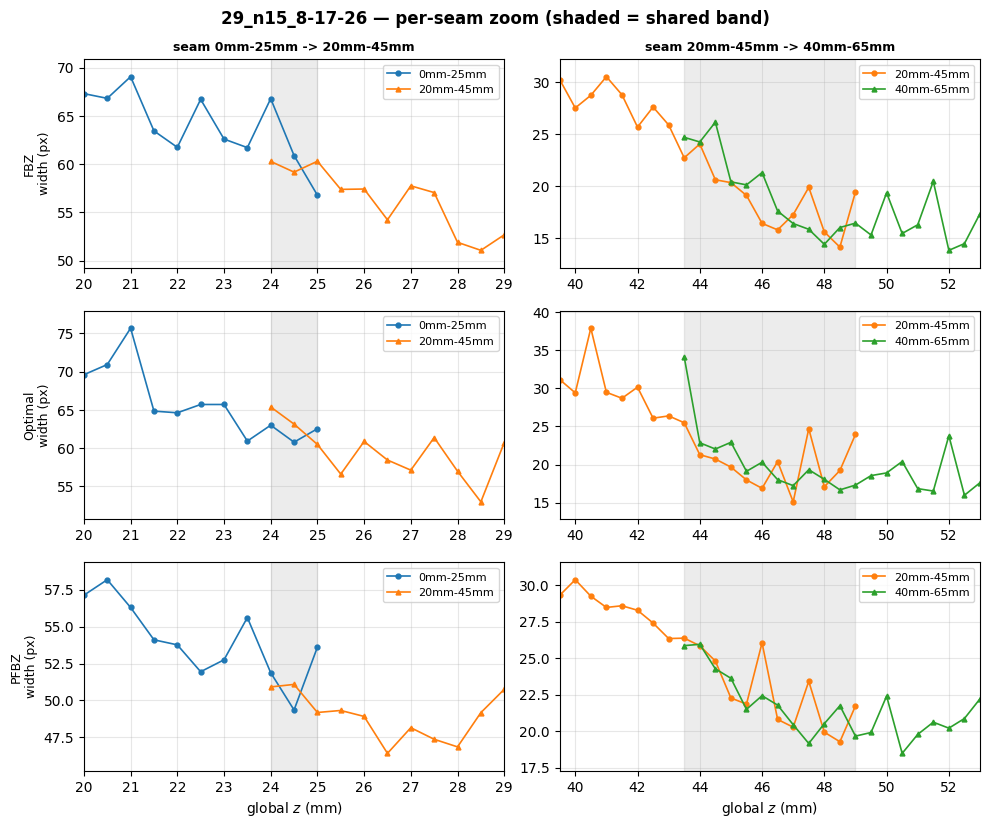

In [9]:
def plot_seam_zoom():
    conds = list(CONDITION_SEGMENTS)
    max_seams = max((len(seams(cond, ell)) for cond in conds for ell in data[cond]), default=0)
    if max_seams == 0:
        print("no seams (single segment) — skipping seam zoom")
        return
    fig, axes = plt.subplots(len(conds), max_seams,
                             figsize=(5.0 * max_seams, 2.8 * len(conds)), squeeze=False)
    for r, cond in enumerate(conds):
        ell = list(data[cond])[0]
        sm = seams(cond, ell)
        for c in range(max_seams):
            ax = axes[r, c]
            if c >= len(sm):
                ax.set_visible(False)
                continue
            left, right = sm[c]
            zl = global_z(data[cond][ell][left], ell)
            zr = global_z(data[cond][ell][right], ell)
            ax.plot(zl, data[cond][ell][left].width_px, "o-", ms=3.5, lw=1.2,
                    color=SEG_COLOURS[left], label=left)
            ax.plot(zr, data[cond][ell][right].width_px, "^-", ms=3.5, lw=1.2,
                    color=SEG_COLOURS[right], label=right)
            lo, hi = max(zl[0], zr[0]), min(zl[-1], zr[-1])
            if hi > lo:
                ax.axvspan(lo, hi, color="grey", alpha=0.15)
                ax.set_xlim(lo - 4, hi + 4)
            else:
                ax.set_xlim(min(zl[-1], zr[0]) - 4, max(zl[-1], zr[0]) + 4)
                ax.text(0.5, 0.9, "no overlap!", transform=ax.transAxes, ha="center",
                        color="crimson", fontweight="bold")
            band = np.concatenate([
                data[cond][ell][left].width_px[(zl >= lo - 4) & (zl <= hi + 4)],
                data[cond][ell][right].width_px[(zr >= lo - 4) & (zr <= hi + 4)],
            ])
            band = band[np.isfinite(band)]
            if band.size:
                pad = 0.1 * (band.max() - band.min() + 1e-9)
                ax.set_ylim(band.min() - pad, band.max() + pad)
            ax.grid(alpha=0.3)
            if r == 0:
                ax.set_title(f"seam {left} -> {right}", fontweight="bold", fontsize=9)
            ax.legend(fontsize=8)
            if c == 0:
                ax.set_ylabel(f"{cond}\nwidth (px)", fontsize=9)
            if r == len(conds) - 1:
                ax.set_xlabel("global $z$ (mm)")
    fig.suptitle(f"{RUN} — per-seam zoom (shaded = shared band)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT_ROOT / "seam_zoom.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_seam_zoom()

## Stitch all segments onto one global-$z$ grid

Identical stitch to the base notebook. Every segment is resampled onto one uniform global grid by
linear interpolation in $z$, then blended with per-segment weights normalised so $\sum_k w_k = 1$
wherever anything is covered:

* **crossfade** — a linear hand-over across each pairwise overlap band.
* **average** — equal weight to every segment covering that $z$.
* **hardcut** — the earlier segment wins up to each overlap midpoint, the later one after.

Each blended map is peak-normalised **after** stitching, so colours are comparable across the scan.

In [10]:
BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    cond: str
    ell: int
    mode: str
    waterfall: np.ndarray   # (n_z, n_s) peak-normalised, on the common global grid
    s_px: np.ndarray
    z_mm: np.ndarray        # (n_z,) uniform global z
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    coverage: np.ndarray    # (n_z,) how many segments cover each row

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src: np.ndarray, water_src: np.ndarray, z_grid: np.ndarray):
    '''Linear-interpolate a (n_z, n_s) map from z_src onto z_grid, per transverse column.'''
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1
        )
    return out, covered


def _blend_weights(mode: str, order: list[str], z_grid: np.ndarray,
                   covers: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    '''Per-segment weight along z, normalised to sum to 1 wherever anything is covered.'''
    order = [lbl for lbl in order if lbl in covers]
    w = {lbl: covers[lbl].astype(float) for lbl in order}

    if mode == "average":
        pass
    elif mode == "hardcut":
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            mid = 0.5 * (z_ov.min() + z_ov.max())
            w[left][both] = np.where(z_ov <= mid, 1.0, 0.0)
            w[right][both] = np.where(z_ov <= mid, 0.0, 1.0)
    else:  # crossfade
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            lo, hi = z_ov.min(), z_ov.max()
            ramp = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo else np.full(z_ov.shape, 0.5)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp

    stack = np.stack([w[lbl] for lbl in order])
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]
    return {lbl: stack[i] for i, lbl in enumerate(order)}


def stitch(cond: str, ell: int, mode: str, z_grid: np.ndarray) -> Stitched:
    order = seg_order(cond, ell)
    sws = {lbl: data[cond][ell][lbl] for lbl in order}
    s_px = sws[order[0]].s_px
    for lbl, sw in sws.items():
        assert np.array_equal(sw.s_px, s_px), f"segment {lbl} cropped to a different extent"

    maps, covers, zs = {}, {}, {}
    for lbl, sw in sws.items():
        z = global_z(sw, ell)
        m, cov = _resample_map(z, sw.waterfall, z_grid)
        maps[lbl], covers[lbl], zs[lbl] = m, cov, z

    weights = _blend_weights(mode, order, z_grid, covers)

    water = np.zeros_like(maps[order[0]])
    for lbl in order:
        water += weights[lbl][:, None] * maps[lbl]

    covered_any = np.any([covers[lbl] for lbl in order], axis=0)
    water[~covered_any] = 0.0
    peak = float(water.max())
    if peak > 0:
        water /= peak

    cy = np.full(z_grid.shape, np.nan)
    cx = np.full(z_grid.shape, np.nan)
    for lbl in order:
        need = np.isnan(cy) & covers[lbl]
        if need.any():
            cy[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_y)
            cx[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_x)

    coverage = np.sum([covers[lbl] for lbl in order], axis=0)
    return Stitched(cond, ell, mode, water, s_px, z_grid, cy, cx, coverage)

### Build one global grid + seam bands per condition, then stitch every blend

Each condition gets its own common grid spanning the union of its placed segments, and its own list
of seam bands for the reference lines.

In [11]:
stitched: dict[str, dict[int, dict[str, Stitched]]] = {}
Z_GRID: dict[str, np.ndarray] = {}
SEAM_BANDS: dict[str, list[tuple[float, float]]] = {}

for cond in CONDITION_SEGMENTS:
    ells = list(data[cond])
    z_hi = max(global_z(data[cond][ell][s], ell)[-1] for ell in ells for s in seg_order(cond, ell))
    z_lo = min(global_z(data[cond][ell][s], ell)[0] for ell in ells for s in seg_order(cond, ell))
    grid = np.arange(z_lo, z_hi + 0.5 * STEP_MM, STEP_MM)
    Z_GRID[cond] = grid

    bands = []
    for left, right in zip(CONDITION_SEGMENTS[cond][:-1], CONDITION_SEGMENTS[cond][1:]):
        los, his = [], []
        for ell in ells:
            if left in data[cond][ell] and right in data[cond][ell]:
                los.append(global_z(data[cond][ell][right], ell)[0])
                his.append(global_z(data[cond][ell][left], ell)[-1])
        if los:
            bands.append((float(np.median(los)), float(np.median(his))))
    SEAM_BANDS[cond] = bands

    stitched[cond] = {ell: {} for ell in ells}
    for ell in ells:
        for mode in BLEND_MODES:
            stitched[cond][ell][mode] = stitch(cond, ell, mode, grid)
        st = stitched[cond][ell]["crossfade"]
        gaps = int((st.coverage == 0).sum())
        note = f"  !! {gaps} uncovered rows" if gaps else ""
        print(f"{cond:>8} l={ell}: {st.waterfall.shape}  z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm"
              f"  brightest {st.brightest_z:.1f} mm{note}")
    print(f"         grid {grid.size} rows {grid[0]:.1f}..{grid[-1]:.1f} mm | "
          f"seams " + ", ".join(f"{lo:.1f}-{hi:.1f}" for lo, hi in bands))

     FBZ l=1: (138, 401)  z 0.0..68.5 mm  brightest 51.0 mm
         grid 138 rows 0.0..68.5 mm | seams 24.0-25.0, 43.5-49.0
 Optimal l=1: (138, 401)  z 0.0..68.5 mm  brightest 51.5 mm
         grid 138 rows 0.0..68.5 mm | seams 24.0-25.0, 43.5-49.0
    PFBZ l=1: (138, 401)  z 0.0..68.5 mm  brightest 50.5 mm
         grid 138 rows 0.0..68.5 mm | seams 24.0-25.0, 43.5-49.0


## Compare the three overlap blends

One row per condition, one column per blend mode, sharing a single 0–1 colourbar. Dashed lines mark
the seam bands. With the segments correctly co-registered the caustic arms should run **straight
through every seam with no kink**.

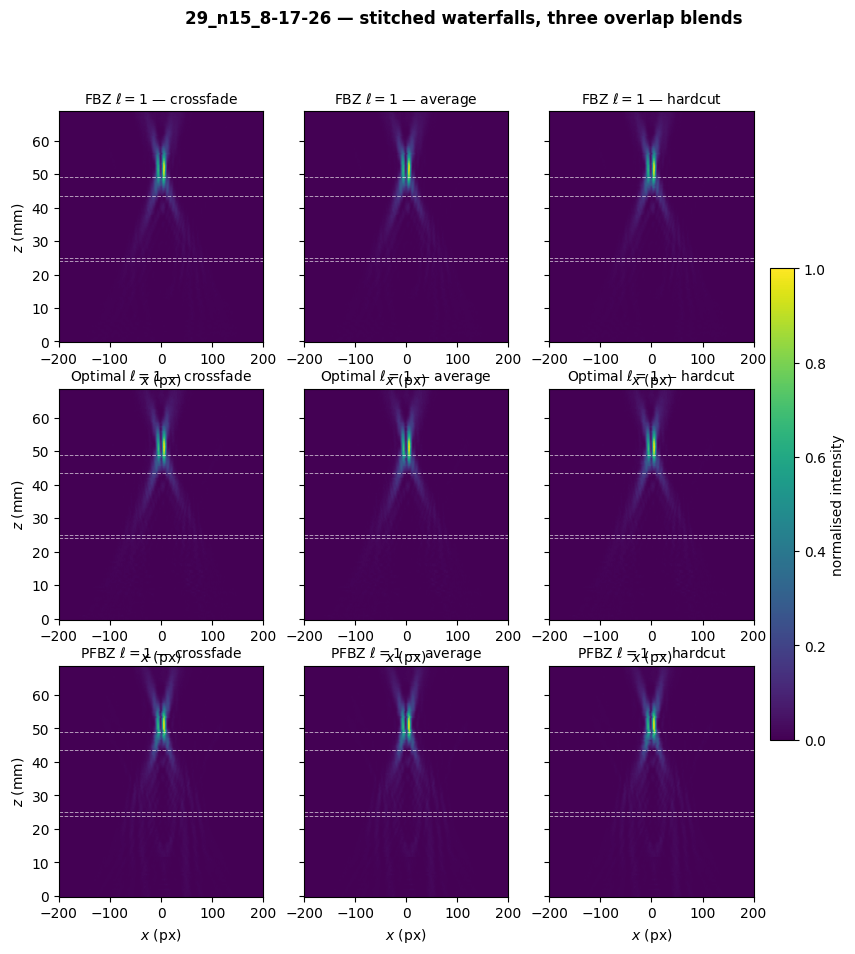

In [12]:
def draw_waterfall(ax, water, s_px, z_mm, title):
    dz = float(np.median(np.diff(z_mm))) if z_mm.size > 1 else STEP_MM
    im = ax.imshow(water, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                   extent=[s_px[0], s_px[-1], z_mm[0] - dz / 2, z_mm[-1] + dz / 2])
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
    ax.set_ylabel("$z$ (mm)")
    ax.set_title(title, fontsize=10)
    return im


def plot_blend_grid():
    conds = list(CONDITION_SEGMENTS)
    fig, axes = plt.subplots(len(conds), len(BLEND_MODES),
                             figsize=(3.2 * len(BLEND_MODES) + 1.2, 3.4 * len(conds)),
                             sharey="row", squeeze=False)
    im = None
    for r, cond in enumerate(conds):
        ell = list(data[cond])[0]
        for c, mode in enumerate(BLEND_MODES):
            st = stitched[cond][ell][mode]
            im = draw_waterfall(axes[r, c], st.waterfall, st.s_px, st.z_mm,
                                f"{cond} $\\ell={ell}$ — {mode}")
            for lo, hi in SEAM_BANDS[cond]:
                for y in (lo, hi):
                    axes[r, c].axhline(y, color="w", ls="--", lw=0.7, alpha=0.6)
            if c > 0:
                axes[r, c].set_ylabel("")
    fig.colorbar(im, ax=axes.ravel().tolist(), label="normalised intensity", pad=0.02, shrink=0.6)
    fig.suptitle(f"{RUN} — stitched waterfalls, three overlap blends", fontweight="bold")
    fig.savefig(OUT_ROOT / "blend_comparison_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_blend_grid()

## Final stitched waterfalls (chosen blend)

Set `CHOSEN_BLEND` to whichever read cleanest above. This writes one PNG per condition under
`outputs/waterfalls_stitched_8-17-26/<cond>/l=1_<axis>.png` plus a combined grid across the three
conditions.

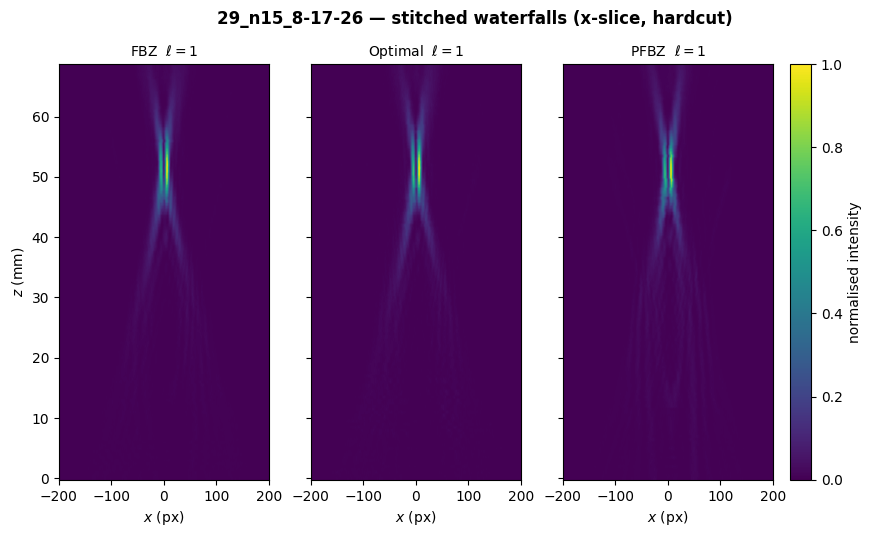

saved per-condition PNGs + grid to outputs/waterfalls_stitched_8-17-26


In [13]:
CHOSEN_BLEND = "hardcut"   # <- set to "crossfade" or "average" after eyeballing the grids above
assert CHOSEN_BLEND in BLEND_MODES


def plot_final():
    conds = list(CONDITION_SEGMENTS)
    group = [(cond, stitched[cond][list(data[cond])[0]][CHOSEN_BLEND]) for cond in conds]
    fig, axes = plt.subplots(1, len(group), figsize=(3.2 * len(group) + 1.5, 5.4),
                             sharey=True, squeeze=False)
    im = None
    for ax, (cond, st) in zip(axes[0], group):
        im = draw_waterfall(ax, st.waterfall, st.s_px, st.z_mm, f"{cond}  $\\ell={st.ell}$")
        ax.set_ylabel("")
    axes[0, 0].set_ylabel("$z$ (mm)")
    fig.colorbar(im, ax=axes[0].tolist(), label="normalised intensity", pad=0.02)
    fig.suptitle(f"{RUN} — stitched waterfalls ({SLICE_AXIS}-slice, {CHOSEN_BLEND})",
                 fontweight="bold")
    fig.savefig(OUT_ROOT / f"{RUN}_grid_{SLICE_AXIS}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    for cond, st in group:
        f, a = plt.subplots(figsize=(5.5, 6.0))
        im = draw_waterfall(a, st.waterfall, st.s_px, st.z_mm,
                            f"{RUN} · {cond}  $\\ell={st.ell}$  ({CHOSEN_BLEND})")
        f.colorbar(im, ax=a, label="normalised intensity")
        f.tight_layout()
        f.savefig(cond_out(cond) / f"l={st.ell}_{SLICE_AXIS}.png", dpi=150)
        plt.close(f)
    print(f"saved per-condition PNGs + grid to {OUT_ROOT.relative_to(REPO_ROOT)}")


plot_final()

## Beam width across the full stitched scan — RMS

Transverse **RMS** beam width of the stitched waterfall for each condition over the whole combined
range. Seam bands shaded; smooth width curves through them confirm the stitch is clean. Focus is
where each curve bottoms out. This is the primary width metric used throughout the notebook.

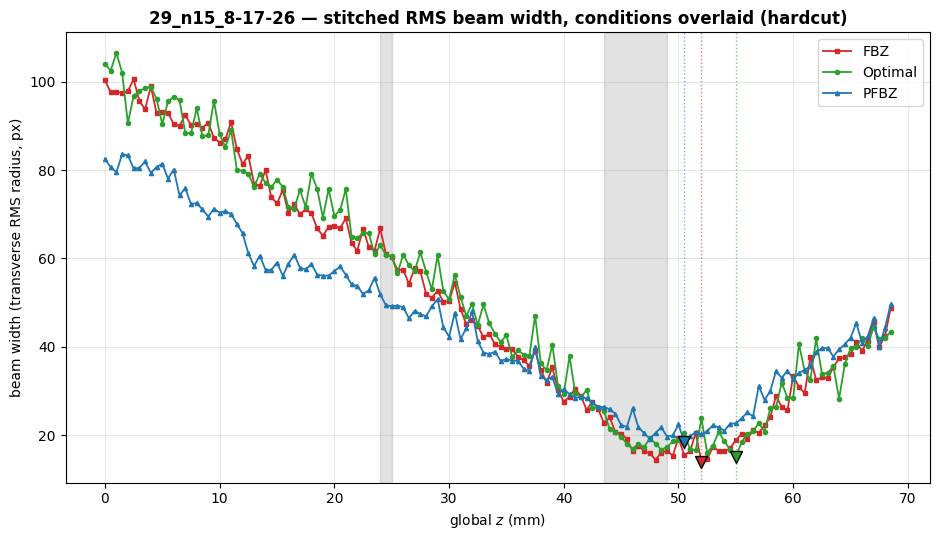

RMS width minimum (focus) per condition:


,condition,ell,z_focus_mm,min_width_px
0,FBZ,1,52.0,13.85
1,Optimal,1,55.0,15.02
2,PFBZ,1,50.5,18.47


In [14]:
def stitched_width(st):
    return np.array([_rms_width(row, st.s_px) for row in st.waterfall])


focus_all = []


def plot_width():
    conds = list(CONDITION_SEGMENTS)
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    style = {"Optimal": ("C2", "o"), "PFBZ": ("C0", "^"), "FBZ": ("C3", "s")}
    for cond in conds:
        ell = list(data[cond])[0]
        st = stitched[cond][ell][CHOSEN_BLEND]
        w = stitched_width(st)
        colour, marker = style.get(cond, ("k", "o"))
        ax.plot(st.z_mm, w, marker + "-", ms=3, lw=1.3, color=colour, label=cond)
        ok = np.isfinite(w) & (st.coverage > 0)
        if ok.any():
            j = int(np.nanargmin(w[ok]))
            z_focus = float(st.z_mm[ok][j])
            ax.axvline(z_focus, color=colour, ls=":", lw=1.0, alpha=0.6)
            ax.plot(z_focus, float(w[ok][j]), "v", color=colour, ms=9, markeredgecolor="k", zorder=5)
            focus_all.append({
                "condition": cond, "ell": ell,
                "z_focus_mm": round(z_focus, 2),
                "min_width_px": round(float(np.nanmin(w[ok])), 2),
            })
    for cond in conds:
        for i, (lo, hi) in enumerate(SEAM_BANDS[cond]):
            ax.axvspan(lo, hi, color="grey", alpha=0.08)
    ax.set_xlabel("global $z$ (mm)")
    ax.set_ylabel("beam width (transverse RMS radius, px)")
    ax.set_title(f"{RUN} — stitched RMS beam width, conditions overlaid ({CHOSEN_BLEND})",
                 fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_ROOT / f"{RUN}_stitched_width_rms.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_width()

focus_table = pd.DataFrame(focus_all).round(2)
print("RMS width minimum (focus) per condition:")
display(focus_table)

## RMS vs LG fit — the one comparison

The **single** place the notebook departs from the RMS metric. Every individual frame of the
stitched waterfall is also fitted to the transverse profile of a Laguerre–Gaussian
$\mathrm{LG}_{0,\ell=1}$ mode. This is *not* a propagation model — each frame gets its own LG mode
whose spot-size $w(z)$ best matches the beam at that distance.

The 1-D intensity along a centred diameter of $\mathrm{LG}_{0,\ell}$ is
$I(s)=A\,(2s^2/w^2)^{|\ell|}\,e^{-2s^2/w^2}$, whose RMS radius is $(w/2)\sqrt{2|\ell|+1}$
($=0.866\,w$ for $\ell=1$). **One panel per condition**: measured RMS (points) with the fitted LG
RMS model overlaid (line), the focus (model minimum) marked. Where the two agree, the RMS is
unbiased; a gap would flag a non-LG-like or clipped profile.

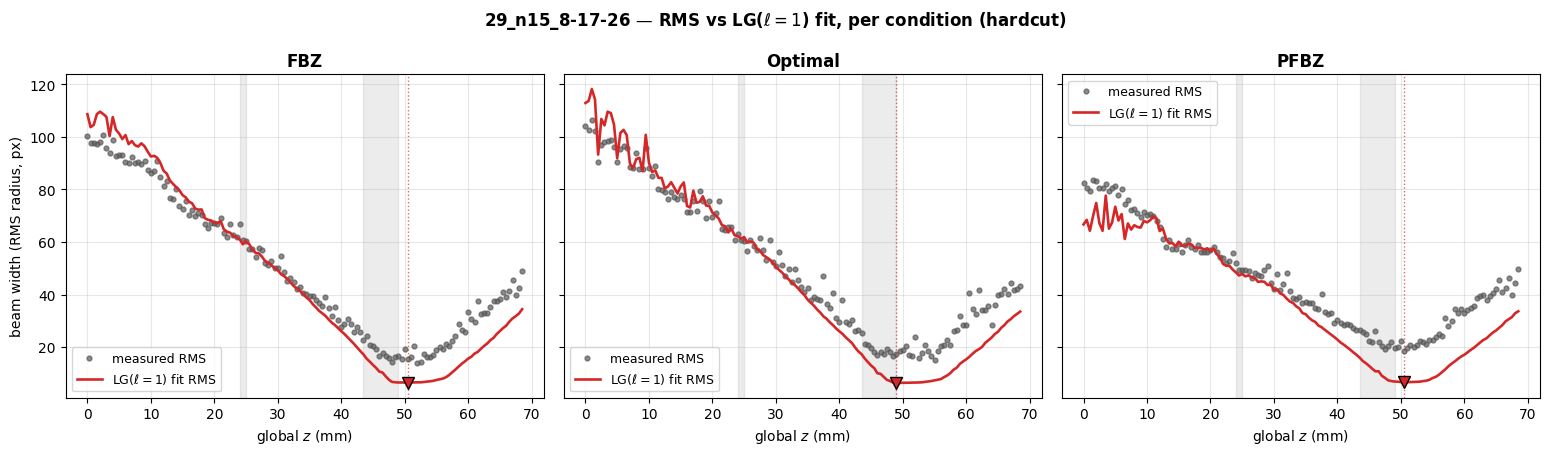

RMS vs LG focus per condition:


,condition,ell,z_focus_rms_mm,min_rms_px,z_focus_lg_mm,waist_w_px,lg_rms_model_px
0,FBZ,1,52.0,13.85,50.5,7.50,6.49
1,Optimal,1,55.0,15.02,49.0,7.29,6.31
2,PFBZ,1,50.5,18.47,50.5,7.63,6.60


In [15]:
from functools import partial
from scipy.optimize import curve_fit


def lg_line_profile(s, amp, w, ell):
    '''Intensity along a centred diameter of LG_{0,|ell|}: A (2 s^2/w^2)^|ell| e^{-2 s^2/w^2}.'''
    x = 2.0 * (np.asarray(s, float) ** 2) / (w * w)
    return amp * x ** abs(ell) * np.exp(-x)


def lg_rms_from_w(w, ell):
    '''1-D RMS radius of that centred LG diameter: (w/2) sqrt(2|ell|+1).'''
    return 0.5 * np.asarray(w, float) * np.sqrt(2 * abs(ell) + 1)


def fit_lg_frame(profile, s_px, ell):
    '''Fit one frame's transverse slice to an LG_{0,ell} diameter; return waist w (px) or nan.'''
    y = np.clip(np.asarray(profile, float), 0, None)
    if not np.isfinite(y).any() or y.max() <= 0:
        return np.nan
    rms = _rms_width(y, s_px)
    if not np.isfinite(rms) or rms <= 0:
        return np.nan
    w0 = 2.0 * rms / np.sqrt(2 * abs(ell) + 1)
    amp0 = y.max() / max((abs(ell) ** abs(ell)) * np.exp(-abs(ell)), 1e-9)
    try:
        popt, _ = curve_fit(partial(lg_line_profile, ell=ell), s_px, y,
                            p0=(amp0, max(w0, 1.0)),
                            bounds=([0.0, 1e-3], [np.inf, np.inf]), maxfev=10000)
    except (RuntimeError, ValueError):
        return np.nan
    return float(popt[1])


def lg_fit_stitched(st):
    '''Per-frame LG waist w(z) and the model RMS width over a stitched waterfall.'''
    w_fit = np.array([
        fit_lg_frame(row, st.s_px, st.ell) if cov > 0 else np.nan
        for row, cov in zip(st.waterfall, st.coverage)
    ])
    return w_fit, lg_rms_from_w(w_fit, st.ell)


lg_focus_all = []


def plot_rms_vs_lg():
    conds = list(CONDITION_SEGMENTS)
    fig, axes = plt.subplots(1, len(conds), figsize=(5.2 * len(conds), 4.6),
                             sharey=True, squeeze=False)
    for ax, cond in zip(axes[0], conds):
        ell = list(data[cond])[0]
        st = stitched[cond][ell][CHOSEN_BLEND]
        meas = stitched_width(st)
        w_fit, rms_model = lg_fit_stitched(st)
        ax.plot(st.z_mm, meas, "o", ms=3.5, color="0.35", alpha=0.7, label="measured RMS")
        ax.plot(st.z_mm, rms_model, "-", lw=1.9, color="tab:red",
                label=r"LG($\ell=1$) fit RMS")
        ok = np.isfinite(rms_model) & (st.coverage > 0)
        if ok.any():
            j = int(np.nanargmin(rms_model[ok]))
            z_focus = float(st.z_mm[ok][j])
            ax.axvline(z_focus, color="tab:red", ls=":", lw=1.0, alpha=0.7)
            ax.plot(z_focus, float(rms_model[ok][j]), "v", color="tab:red", ms=9,
                    markeredgecolor="k", zorder=5)
            okr = np.isfinite(meas) & (st.coverage > 0)
            z_focus_rms = float(st.z_mm[okr][int(np.nanargmin(meas[okr]))])
            lg_focus_all.append({
                "condition": cond, "ell": ell,
                "z_focus_rms_mm": round(z_focus_rms, 2),
                "min_rms_px": round(float(np.nanmin(meas[okr])), 2),
                "z_focus_lg_mm": round(z_focus, 2),
                "waist_w_px": round(float(w_fit[ok][j]), 2),
                "lg_rms_model_px": round(float(rms_model[ok][j]), 2),
            })
        for lo, hi in SEAM_BANDS[cond]:
            ax.axvspan(lo, hi, color="grey", alpha=0.15)
        ax.set_title(cond, fontweight="bold")
        ax.set_xlabel("global $z$ (mm)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
    axes[0, 0].set_ylabel("beam width (RMS radius, px)")
    fig.suptitle(f"{RUN} — RMS vs LG($\\ell=1$) fit, per condition ({CHOSEN_BLEND})",
                 fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT_ROOT / f"{RUN}_rms_vs_lg.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_rms_vs_lg()

lg_focus_table = pd.DataFrame(lg_focus_all)
print("RMS vs LG focus per condition:")
display(lg_focus_table)

## Beam width across the full stitched scan — LG waist

Same overlay as the RMS width figure above, but the width metric is the fitted Laguerre–Gaussian
spot size $w(z)$ rather than the transverse RMS radius. Each frame of the stitched waterfall is fit
to the $\mathrm{LG}_{0,\ell=1}$ diameter profile and its waist $w$ (px) is plotted for every
condition over the whole combined range. Seam bands shaded; focus is where each waist curve bottoms
out. (The two metrics are proportional — $\mathrm{RMS}=0.866\,w$ for $\ell=1$ — so the focus
locations coincide with the RMS figure; this view reports the waist directly.)

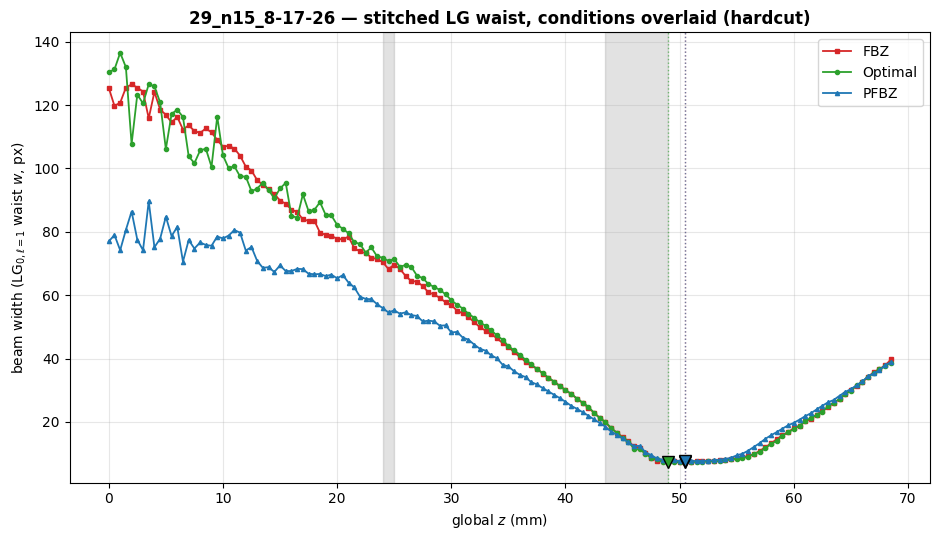

LG waist minimum (focus) per condition:


,condition,ell,z_focus_mm,min_waist_w_px
0,FBZ,1,50.5,7.50
1,Optimal,1,49.0,7.29
2,PFBZ,1,50.5,7.63


In [16]:
lg_waist_focus_all = []


def plot_width_lg():
    conds = list(CONDITION_SEGMENTS)
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    style = {"Optimal": ("C2", "o"), "PFBZ": ("C0", "^"), "FBZ": ("C3", "s")}
    for cond in conds:
        ell = list(data[cond])[0]
        st = stitched[cond][ell][CHOSEN_BLEND]
        w_fit, _ = lg_fit_stitched(st)
        colour, marker = style.get(cond, ("k", "o"))
        ax.plot(st.z_mm, w_fit, marker + "-", ms=3, lw=1.3, color=colour, label=cond)
        ok = np.isfinite(w_fit) & (st.coverage > 0)
        if ok.any():
            j = int(np.nanargmin(w_fit[ok]))
            z_focus = float(st.z_mm[ok][j])
            ax.axvline(z_focus, color=colour, ls=":", lw=1.0, alpha=0.6)
            ax.plot(z_focus, float(w_fit[ok][j]), "v", color=colour, ms=9,
                    markeredgecolor="k", zorder=5)
            lg_waist_focus_all.append({
                "condition": cond, "ell": ell,
                "z_focus_mm": round(z_focus, 2),
                "min_waist_w_px": round(float(np.nanmin(w_fit[ok])), 2),
            })
    for cond in conds:
        for lo, hi in SEAM_BANDS[cond]:
            ax.axvspan(lo, hi, color="grey", alpha=0.08)
    ax.set_xlabel("global $z$ (mm)")
    ax.set_ylabel(r"beam width (LG$_{0,\ell=1}$ waist $w$, px)")
    ax.set_title(f"{RUN} — stitched LG waist, conditions overlaid ({CHOSEN_BLEND})",
                 fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_ROOT / f"{RUN}_stitched_width_lg.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_width_lg()

lg_waist_focus_table = pd.DataFrame(lg_waist_focus_all).round(2)
print("LG waist minimum (focus) per condition:")
display(lg_waist_focus_table)


## Clipping & on-axis intensity

Ported from `waterfall_l1_exposure_compare.ipynb`. **One 3-panel figure per condition**, each panel
overlaying that condition's three segments on the global $z$ axis:

* **left** — raw per-frame maximum vs $z$ against the 10-bit clip level (1022). Anything riding the
  ceiling would flat-top the peak and bias the RMS upward.
* **middle** — number of pixels pinned at the clip level per frame (how much of the peak is
  destroyed).
* **right** — on-axis (central-column) counts vs $z$, background-subtracted.

For this acquisition every trace should sit well under the ceiling — the widths above are clean.

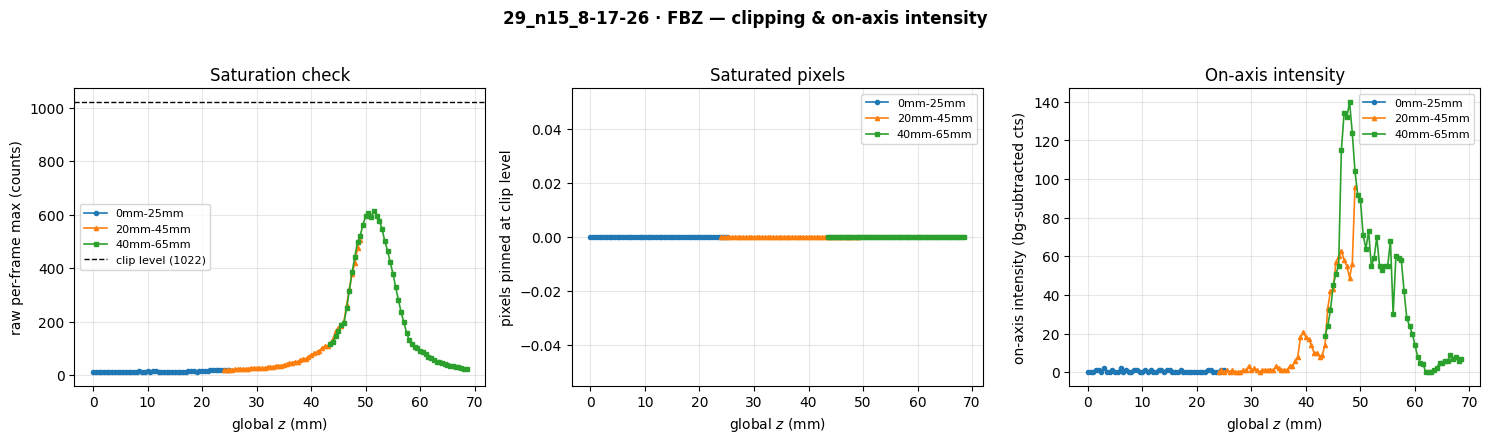

     FBZ  0mm-25mm: raw frame max =    20 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis     2 cts
     FBZ 20mm-45mm: raw frame max =   505 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis    96 cts
     FBZ 40mm-65mm: raw frame max =   615 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis   140 cts


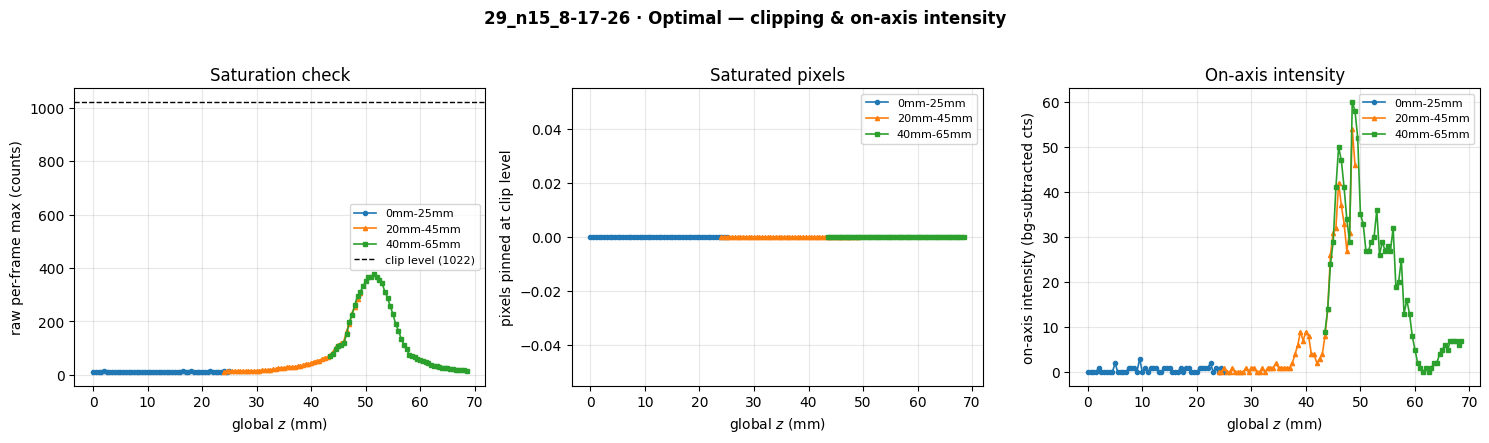

 Optimal  0mm-25mm: raw frame max =    14 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis     3 cts
 Optimal 20mm-45mm: raw frame max =   306 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis    54 cts
 Optimal 40mm-65mm: raw frame max =   376 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis    60 cts


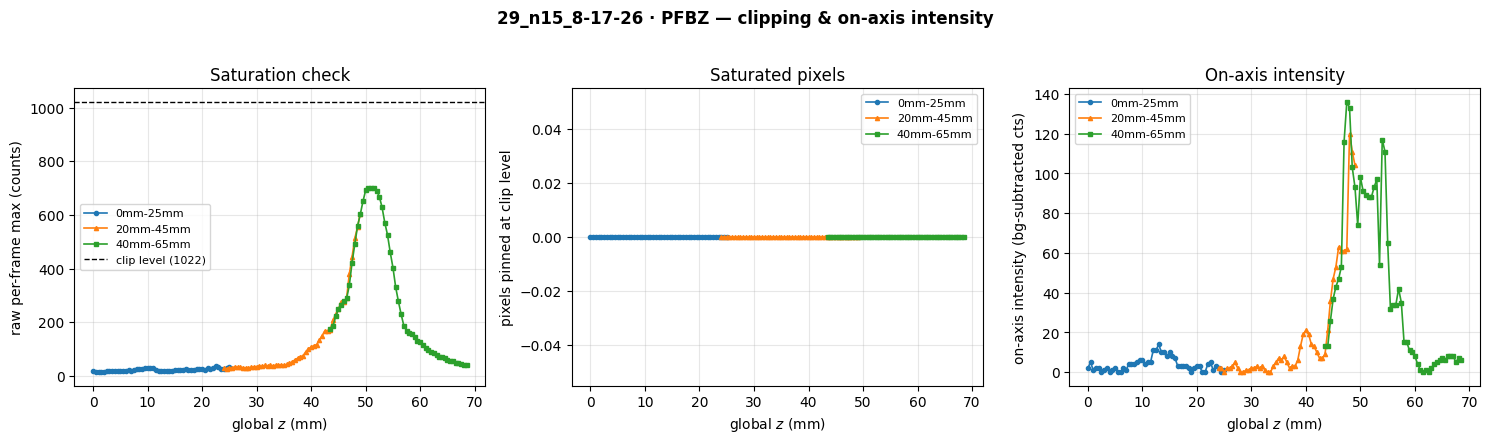

    PFBZ  0mm-25mm: raw frame max =    38 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis    14 cts
    PFBZ 20mm-45mm: raw frame max =   605 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis   120 cts
    PFBZ 40mm-65mm: raw frame max =   702 cts | 0 of 51 frames saturated (max 0 px/frame) | peak on-axis   136 cts


In [17]:
def plot_clipping(cond: str):
    ell = list(data[cond])[0]
    order = seg_order(cond, ell)
    fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(15, 4.3))
    for seg in order:
        sw = data[cond][ell][seg]
        z = global_z(sw, ell)
        c, m = SEG_COLOURS[seg], SEG_MARKERS[seg][0]
        axL.plot(z, sw.frame_max_raw, m + "-", ms=3, lw=1.2, color=c, label=seg)
        axM.plot(z, sw.n_saturated, m + "-", ms=3, lw=1.2, color=c, label=seg)
        axR.plot(z, sw.onaxis, m + "-", ms=3, lw=1.2, color=c, label=seg)

    axL.axhline(SAT_LEVEL, color="k", ls="--", lw=1, label=f"clip level ({SAT_LEVEL})")
    axL.set_xlabel("global $z$ (mm)"); axL.set_ylabel("raw per-frame max (counts)")
    axL.set_title("Saturation check"); axL.legend(fontsize=8); axL.grid(alpha=0.3)

    axM.set_xlabel("global $z$ (mm)"); axM.set_ylabel("pixels pinned at clip level")
    axM.set_title("Saturated pixels"); axM.legend(fontsize=8); axM.grid(alpha=0.3)

    axR.set_xlabel("global $z$ (mm)"); axR.set_ylabel("on-axis intensity (bg-subtracted cts)")
    axR.set_title("On-axis intensity"); axR.legend(fontsize=8); axR.grid(alpha=0.3)

    fig.suptitle(f"{RUN} · {cond} — clipping & on-axis intensity", fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(cond_out(cond) / f"{cond}_clipping_and_onaxis.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    for seg in order:
        sw = data[cond][ell][seg]
        nsat = int((sw.n_saturated > 0).sum())
        print(f"{cond:>8} {seg:>9}: raw frame max = {sw.frame_max_raw.max():5.0f} cts | "
              f"{nsat} of {sw.z_local.size} frames saturated "
              f"(max {int(sw.n_saturated.max())} px/frame) | "
              f"peak on-axis {sw.onaxis.max():5.0f} cts")


for cond in CONDITION_SEGMENTS:
    plot_clipping(cond)

## Centroid diagnostic across the stitched scan

Per condition: the centroid on the global $z$ grid, seams dashed. A discontinuity at a seam means
the two segments' beams sit at different sensor positions — harmless for the centred waterfall, but
worth seeing. The bottom panel shows **segment coverage** (1 = single segment, 2 = inside an
overlap, 0 = a gap).

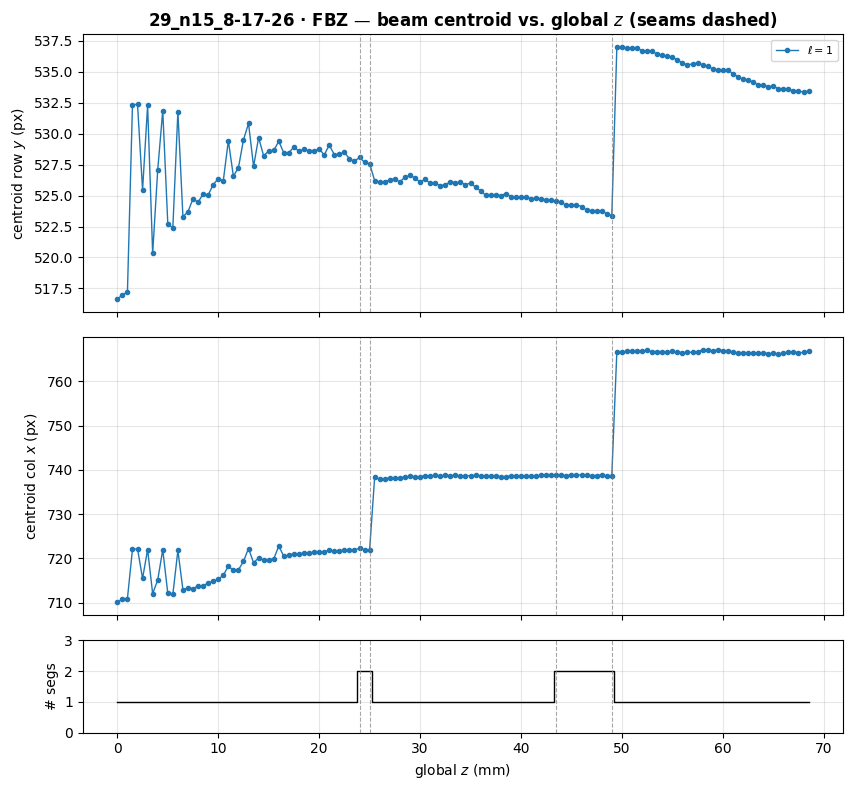

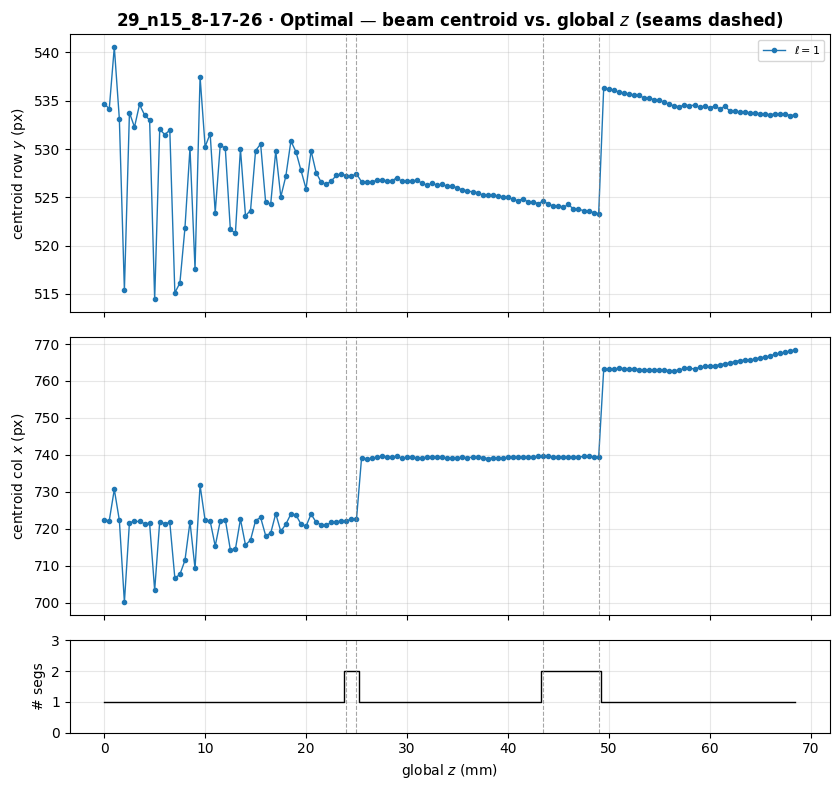

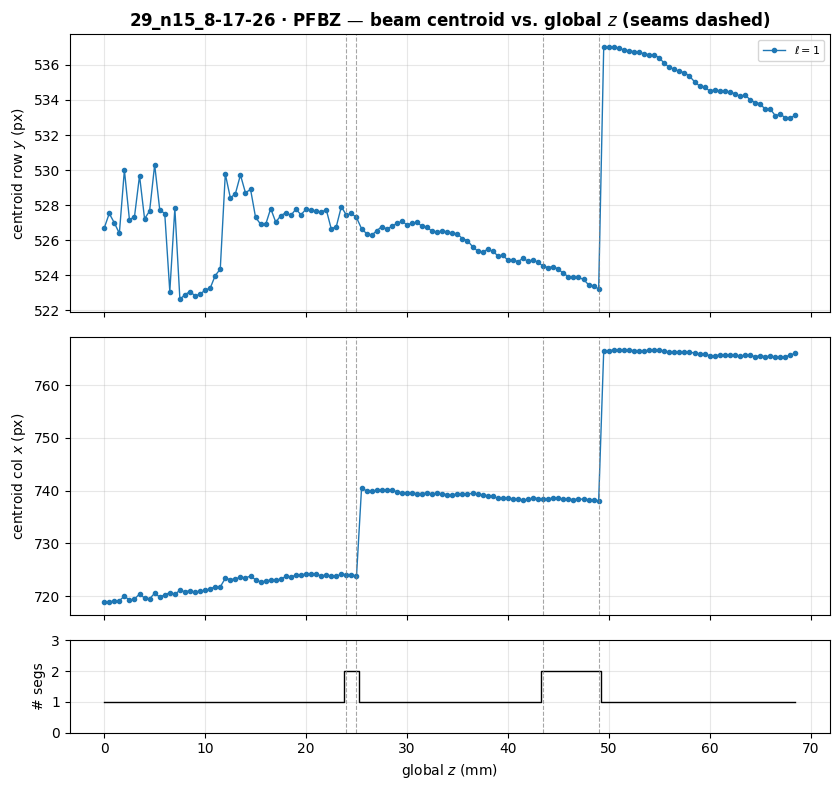

In [18]:
def plot_centroids(cond: str):
    ell = list(data[cond])[0]
    st = stitched[cond][ell][CHOSEN_BLEND]
    fig, axes = plt.subplots(3, 1, figsize=(8.5, 8), sharex=True,
                             gridspec_kw={"height_ratios": [3, 3, 1]})
    axes[0].plot(st.z_mm, st.centroid_y, "o-", ms=3, lw=1, color="C0", label=f"$\\ell={ell}$")
    axes[1].plot(st.z_mm, st.centroid_x, "o-", ms=3, lw=1, color="C0")
    axes[2].step(st.z_mm, st.coverage, where="mid", color="k", lw=1)
    axes[2].set_ylabel("# segs")
    axes[2].set_yticks([0, 1, 2, 3])
    for ax in axes:
        for lo, hi in SEAM_BANDS[cond]:
            for y in (lo, hi):
                ax.axvline(y, color="grey", ls="--", lw=0.8, alpha=0.7)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("centroid row $y$ (px)")
    axes[0].set_title(f"{RUN} · {cond} — beam centroid vs. global $z$ (seams dashed)",
                      fontweight="bold")
    axes[0].legend(fontsize=8)
    axes[1].set_ylabel("centroid col $x$ (px)")
    axes[2].set_xlabel("global $z$ (mm)")
    fig.tight_layout()
    fig.savefig(cond_out(cond) / f"{cond}_centroids.png", dpi=150)
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_centroids(cond)

## Summary table

One row per condition for the chosen blend: the stitched $z$ span, the brightest-frame $z$, the RMS
and LG focus, and the per-segment clipping/on-axis peaks. Written to
`outputs/waterfalls_stitched_8-17-26/<RUN>_summary.csv`.

In [19]:
rms_focus = {(r["condition"]): r for r in focus_all}
lg_focus = {(r["condition"]): r for r in lg_focus_all}

rows = []
for cond in CONDITION_SEGMENTS:
    ell = list(data[cond])[0]
    st = stitched[cond][ell][CHOSEN_BLEND]
    order = seg_order(cond, ell)
    row = {
        "run": RUN, "condition": cond, "ell": ell, "blend": CHOSEN_BLEND,
        "n_frames": st.z_mm.size,
        "z_min_mm": round(float(st.z_mm.min()), 2), "z_max_mm": round(float(st.z_mm.max()), 2),
        "brightest_z_mm": round(st.brightest_z, 2),
        "focus_z_rms_mm": rms_focus.get(cond, {}).get("z_focus_mm", np.nan),
        "min_width_rms_px": rms_focus.get(cond, {}).get("min_width_px", np.nan),
        "focus_z_lg_mm": lg_focus.get(cond, {}).get("z_focus_lg_mm", np.nan),
        "lg_waist_px": lg_focus.get(cond, {}).get("waist_w_px", np.nan),
        "lg_rms_model_px": lg_focus.get(cond, {}).get("lg_rms_model_px", np.nan),
        "peak_onaxis_cts": round(float(max(data[cond][ell][s].onaxis.max() for s in order)), 1),
        "raw_frame_max_cts": round(float(max(data[cond][ell][s].frame_max_raw.max() for s in order)), 1),
        "saturated_frames": int(sum(int((data[cond][ell][s].n_saturated > 0).sum()) for s in order)),
    }
    for seg in CONDITION_SEGMENTS[cond]:
        row[f"start_{seg}_mm"] = (round(STARTS_MM[cond][ell][seg], 2)
                                  if seg in STARTS_MM[cond][ell] else np.nan)
    rows.append(row)

summary = pd.DataFrame(rows).round(2)
summary.to_csv(OUT_ROOT / f"{RUN}_summary.csv", index=False)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 220):
    display(summary)
print(f"\nsaved {RUN}_summary.csv to {OUT_ROOT.relative_to(REPO_ROOT)}")

,run,condition,ell,blend,n_frames,z_min_mm,z_max_mm,brightest_z_mm,focus_z_rms_mm,min_width_rms_px,focus_z_lg_mm,lg_waist_px,lg_rms_model_px,peak_onaxis_cts,raw_frame_max_cts,saturated_frames,start_0mm-25mm_mm,start_20mm-45mm_mm,start_40mm-65mm_mm
0,29_n15_8-17-26,FBZ,1,hardcut,138,0.0,68.5,51.0,52.0,13.85,50.5,7.50,6.49,140.0,615.0,0,0.0,24.0,43.5
1,29_n15_8-17-26,Optimal,1,hardcut,138,0.0,68.5,51.5,55.0,15.02,49.0,7.29,6.31,60.0,376.0,0,0.0,24.0,43.5
2,29_n15_8-17-26,PFBZ,1,hardcut,138,0.0,68.5,50.5,50.5,18.47,50.5,7.63,6.60,136.0,702.0,0,0.0,24.0,43.5



saved 29_n15_8-17-26_summary.csv to outputs/waterfalls_stitched_8-17-26
